# AA 203 — Homework 1
## Problem 1.1 — Gradient descent and line search


### a)

Using the NSC Theorem, given that $f$ is twice differentiable,
$\nabla f(x^*) = 0$ and $\nabla^2 f(x^*)$ is positive semi-definite for any candidate local minimum $x^*$.
Since $f(x) \in C^2$,

$$\nabla f(x^*) = Q x^* - b = 0 \quad\text{and}\quad \nabla^2 f(x^*) = Q \;\longrightarrow\; (\text{positive-definite matrix})$$

$$\Longrightarrow \; \boxed{\,x^* = Q^{-1} b\,}$$

Let's use $Q$ is symmetric positive-definite $\Longrightarrow$ this also implies $x^*$ is actually a strict local minimum.

**Prove $x^*$ is a global minimum**
- $f$ is defined on $\mathbb{R}^n$ that is open
- $\forall x \in \mathbb{R}^n$, $\nabla^2 f(x) = Q$ is positive-definite $\Longrightarrow$ $f$ is strictly convex
- Therefore the NSC is actually a necessary and sufficient condition, proving $x^* = Q^{-1} b$ is a unique global minimum.


### b) Using Newton method

$$
\begin{aligned}
x^{(k+1)} &= x^{(k)} - [\nabla^2 f(x^{(k)})]^{-1}\, \nabla f(x^{(k)}) \\
          &= x^{(k)} - Q^{-1}(Q x^{(k)} - b) \\
          &= x^{(k)} - x^{(k)} + Q^{-1} b \\
          &= Q^{-1} b = x^*
\end{aligned}
$$

$\Longrightarrow$ we get to $x^*$ in one step.

The downside is that we need to compute $Q^{-1}$ which on average is $\mathcal{O}(n^3)$ in time and $\mathcal{O}(n^2)$ in memory. For $n \gg 10^4$, which can be very computationally challenging. Also this inversion of $Q$ is unstable, which is only possible due to the assumed structure of the matrix (symmetric definite positive).


### c)

$$\lVert S x \rVert_2 = \lVert U \Sigma U^\top x \rVert_2 = \lVert \Sigma U^\top x \rVert_2 \quad \text{(because } U \text{ is orthogonal)}, \quad \forall x \in \mathbb{R}^n.$$



$$
\forall z \in \mathbb{R}^n.
\Sigma z \;=\;
\begin{pmatrix} \mu_1 & & \\ & \ddots & \\ & & \mu_n \end{pmatrix}
\begin{pmatrix} z_1 \\ \vdots \\ z_n \end{pmatrix}
\;=\;
\begin{pmatrix} \mu_1 z_1 \\ \vdots \\ \mu_n z_n \end{pmatrix}
$$

Since for all $i$, $\mu_i^{\,2} \le \big(\max_{j \in \{1,\dots,n\}} |\mu_j|\big)^{2}$, we get

$$\lVert \Sigma z \rVert_2 = \sqrt{\sum_i \mu_i^{\,2} z_i^{\,2}} \;\le\; \max_{i \in \{1,\dots,n\}} |\mu_i|\, \sqrt{\sum_i z_i^{\,2}} \;=\; \max_{i \in \{1,\dots,n\}} |\mu_i|\, \lVert z \rVert_2$$

$$\Longrightarrow\; \lVert \Sigma z \rVert_2 \le \max_{i \in \{1,\dots,n\}} |\mu_i|\, \lVert z \rVert_2$$

$\forall x \in \mathbb{R}^n$,

$$\lVert S x \rVert_2 = \lVert \Sigma U^\top x \rVert_2 \;\le\; \max_{i \in \{1,\dots,n\}} |\mu_i|\, \lVert U^\top x \rVert_2 = \max_{i \in \{1,\dots,n\}} |\mu_i|\, \lVert x \rVert_2 \quad \text{because } U^\top \text{ is orthogonal}$$

$$\text{Thus } \;\boxed{\, \lVert S x \rVert_2 \;\le\; \max_{i \in \{1,\dots,n\}} |\mu_i|\, \lVert x \rVert_2 \,}$$


### d)

$Q$ is a symmetric, definite positive matrix $\longrightarrow$ spectral theorem implies
$$\exists\, U \in \mathbb{R}^{n\times n}\ \text{orthogonal s.t.}\ Q = U\, \Sigma_Q\, U^\top \quad \text{where } \Sigma_Q = \mathrm{diag}(\lambda_1,\dots,\lambda_n).$$

Note $\;e_i = (0, \dots, \underset{\substack{\uparrow \\ i\text{th pos}}}{1}, \dots, 0)^\top\;$ the canonical base of $\mathbb{R}^n$, and $v_i = U e_i$.

$$
\begin{aligned}
(I - \eta Q)\, v_i
&= (I - \eta Q)\, U e_i \\
&= U e_i - \eta\, U \Sigma_Q U^\top U e_i \\
&= U e_i - \eta\, U \Sigma_Q\, e_i \\
&= U e_i - \eta\, \lambda_i\, U e_i \\
&= (1 - \eta \lambda_i)\, U e_i \\
&= (1 - \eta \lambda_i)\, v_i \qquad\checkmark \quad (**)
\end{aligned}
$$

Thus $(I - \eta Q)\, v_i = (1 - \eta \lambda_i)\, v_i$, and $(v_i)$, $i = 1,\dots,n$ is another base of $\mathbb{R}^n$ since $U$ is orthogonal. $(**)$

For each $i$, $(1 - \eta \lambda_i)$ is an eigenvalue of $I - \eta Q$ due to $(**)$.


### e)

For $k \ge 0$,

$$
\begin{aligned}
\delta^{(k+1)} &= \lVert x^{(k+1)} - x^* \rVert_2 \\
&= \big\lVert x^{(k)} - \eta (Q x^{(k)} - b) - \big[\, x^* - \underbrace{\eta (Q x^* - b)}_{= 0} \,\big] \big\rVert_2 \qquad \text{(since } \nabla f(x^*) = Q x^* - b = 0\text{)} \\
&= \lVert [I - \eta Q]\, x^{(k)} + \eta b - [I - \eta Q]\, x^* - \eta b \rVert_2 \\
&= \lVert [I - \eta Q]\,[x^{(k)} - x^*] \rVert_2 \\
&\le \max_{i \in \{1,\dots,n\}} |1 - \eta \lambda_i| \cdot \lVert x^{(k)} - x^* \rVert_2
\end{aligned}
$$

using question c) (Note that since $Q$ is symmetric "$S = I - \eta Q$" is also symmetric, so c) applies in here, and in d) we computed the eigen values).

$$\Longrightarrow\; \delta^{(k+1)} \le \gamma(\eta)\, \delta^{(k)}$$

By recursion, since all these are positive we have:
$$\forall k \ge 0, \qquad \delta^{(k)} \le \gamma(\eta)^k \cdot \underbrace{\delta^{(0)}}_{=\,\lVert x^{(0)} - x^* \rVert_2\, =\, \delta_0}$$


### f)

$d^{(k)} = -\nabla f(x^{(k)})$. Define $g(\eta) = f(x^{(k)} + \eta\, d^{(k)})$.

$$
\begin{aligned}
g'(\eta) &= (x^{(k)})^\top Q\, d^{(k)} + \eta\, d^{(k)\top} Q\, d^{(k)} - b^\top d^{(k)} \\
         &= d^{(k)\top}(Q x^{(k)} - b) + \eta\, d^{(k)\top} Q\, d^{(k)}
\end{aligned}
$$

Let's find $\eta^*$: $\eta$ unconstrained optimization problem, so
$$\min_{\eta \ge 0} g(\eta)$$
— since we have a 1D convex problem defined on the positive reals, a necessary and sufficient condition is

$$g'(\eta) = 0$$

$$0 = d^{(k)\top}\big(Q(x^{(k)} + \eta\, d^{(k)}) - b\big) = d^{(k)\top}\big[(Q x^{(k)} - b) + \eta\, Q d^{(k)}\big]$$

$$0 = d^{(k)\top}(-d^{(k)}) + \eta\, d^{(k)\top} Q\, d^{(k)}
\qquad \underbrace{\big(\,=\, -\lVert d^{(k)} \rVert_2^{\,2}\,\big)}$$

$$\eta^{*} = \frac{\lVert d^{(k)} \rVert_2^{\,2}}{d^{(k)\top} Q\, d^{(k)}}$$

$\eta^*$ happens to be the global minimum of $g$ defined on $\mathbb{R}$, hence it is also a global minimum of $g$ on $\mathbb{R}^+$.

$$\Longrightarrow\; \eta^{(k)} = \arg\min_{\eta \ge 0} f(x^{(k)} + \eta\, d^{(k)}) = \frac{\lVert d^{(k)} \rVert_2^{\,2}}{d^{(k)\top} Q\, d^{(k)}}$$


### g)

$$f(x) = \tfrac{1}{2}\,x_1^{\,2} + \gamma\, x_2^{\,2} \cdot \tfrac{1}{2} = \tfrac{1}{2}\, x^\top Q x - b^\top x$$

For
$$Q = \begin{pmatrix} 1 & 0 \\ 0 & \gamma \end{pmatrix}, \qquad b = \begin{pmatrix} 0 \\ 0 \end{pmatrix}.$$

Please see code.


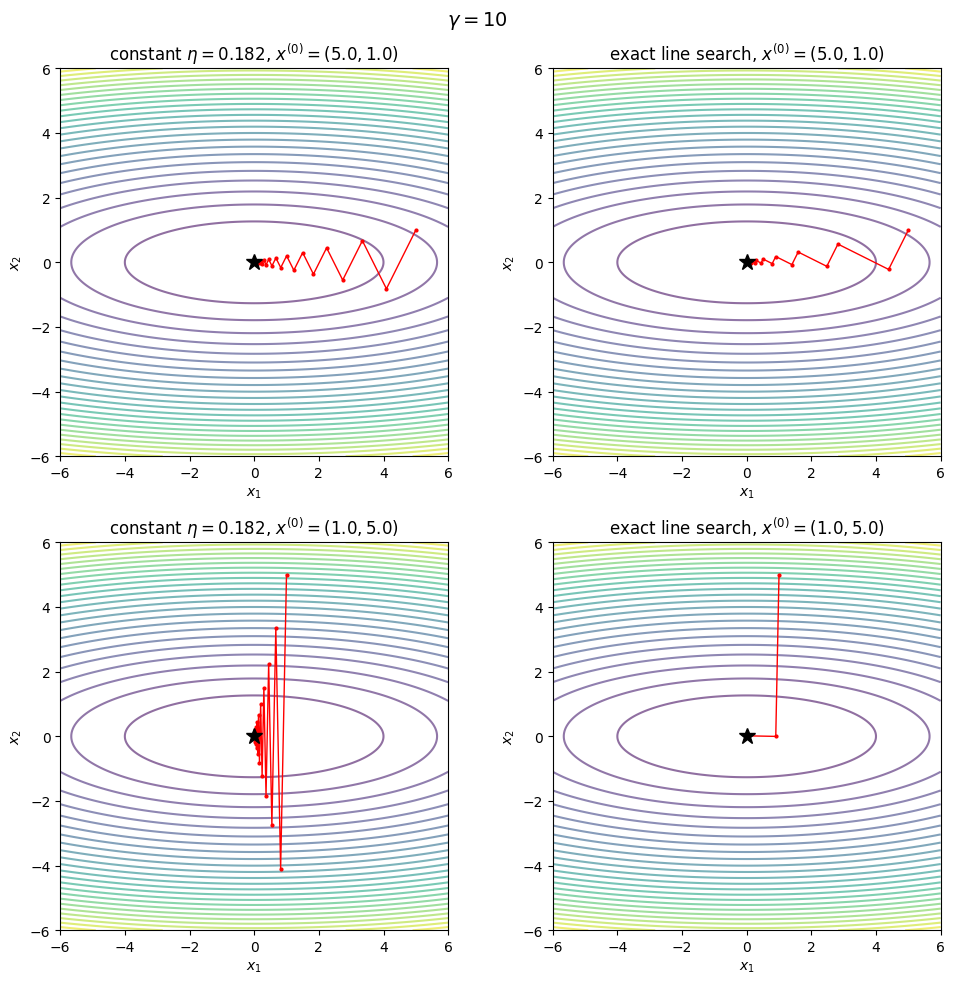

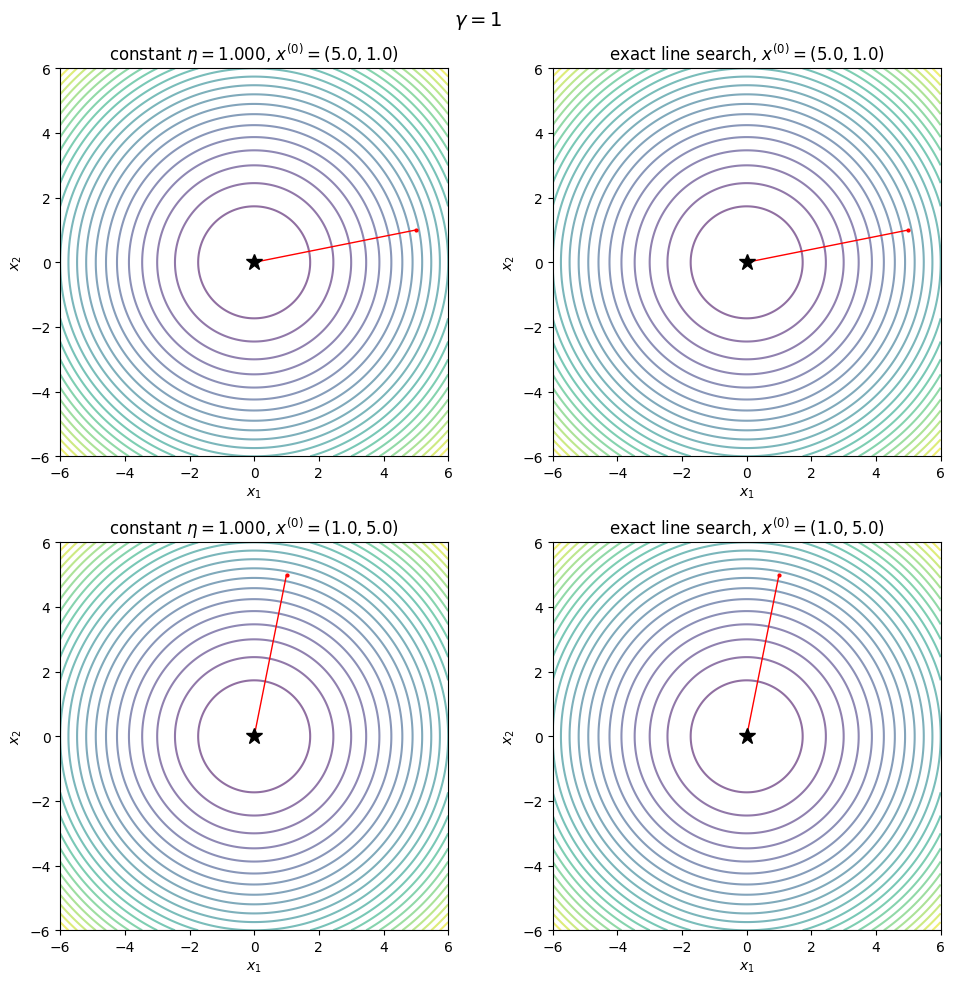

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gd_const(Q, x0, eta, n_iters=60):
    xs = [np.asarray(x0, dtype=float)]
    for _ in range(n_iters):
        xs.append(xs[-1] - eta * (Q @ xs[-1]))
    return np.array(xs)

def gd_linesearch(Q, x0, n_iters=60, tol=1e-12):
    xs = [np.asarray(x0, dtype=float)]
    for _ in range(n_iters):
        d = -Q @ xs[-1]
        if np.linalg.norm(d) < tol:
            break
        eta = (d @ d) / (d @ Q @ d)
        xs.append(xs[-1] + eta * d)
    return np.array(xs)

def plot_traj(ax, Q, traj, title, lim=6):
    g = np.linspace(-lim, lim, 300)
    X, Y = np.meshgrid(g, g)
    Z = 0.5 * (Q[0, 0] * X**2 + Q[1, 1] * Y**2)
    ax.contour(X, Y, Z, levels=25, cmap="viridis", alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], "r.-", lw=1, ms=4)
    ax.plot(0, 0, "k*", ms=12)
    ax.set_title(title)
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
    ax.set_aspect("equal")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

starts = [(5.0, 1.0), (1.0, 5.0)]

for gamma in (10, 1):
    Q = np.diag([1.0, float(gamma)])
    eta = 2.0 / (1.0 + gamma)  # 2 / (lambda_min + lambda_max)
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    for i, x0 in enumerate(starts):
        tc = gd_const(Q, x0, eta=eta)
        tl = gd_linesearch(Q, x0)
        plot_traj(axes[i, 0], Q, tc, f"constant $\\eta={eta:.3f}$, $x^{{(0)}}={x0}$")
        plot_traj(axes[i, 1], Q, tl, f"exact line search, $x^{{(0)}}={x0}$")
    fig.suptitle(fr"$\gamma = {gamma}$", fontsize=14)
    plt.tight_layout()
    plt.show()


**Observations.**

Exact line search always reaches $x^* = (0,0)$. For $\gamma = 10$ the iterates zig-zag: consecutive line-search directions are orthogonal (since $\nabla f(x^{(k+1)})^\top d^{(k)} = g'(\eta^{(k)}) = 0$), and the bigger the condition number $\gamma$, the more severe the zig-zag. For $\gamma = 1$ the level sets are circles, the gradient points straight at $x^*$, and we converge in a single iteration from any starting point.

Constant step size needs $\eta < 2/\lambda_{\max} = 2/\gamma$ to be stable (from (e), $\gamma(\eta) < 1$). The best constant step is $\eta^\star = 2/(\lambda_{\min} + \lambda_{\max}) = 2/(1 + \gamma)$, with contraction factor $(\gamma-1)/(\gamma+1)$. For $\gamma = 10$ that is $9/11 \approx 0.82$, so progress is slow and we see the same zig-zag as with exact line search. If $\eta$ is too large the iteration diverges; too small and progress crawls. For $\gamma = 1$, $\eta^\star = 1$ also gives one-step convergence.
